1. Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
df = pd.read_csv('/content/tmdb-movies.csv', encoding='latin-1')


2. Quick Overview

In [ ]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(3853, 13)
   popularity     budget     revenue                original_title  \
0   32.985763  150000000  1513528810                Jurassic World   
1   28.419936  150000000   378436354            Mad Max: Fury Road   
2   13.112507  110000000   295238201                     Insurgent   
3   11.173104  200000000  2068178225  Star Wars: The Force Awakens   
4    9.335014  190000000  1506249360                     Furious 7   

                                                cast          director  \
0  Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...   Colin Trevorrow   
1  Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...     George Miller   
2  Shailene Woodley|Theo James|Kate Winslet|Ansel...  Robert Schwentke   
3  Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...       J.J. Abrams   
4  Vin Diesel|Paul Walker|Jason Statham|Michelle ...         James Wan   

   runtime     genres  vote_count  vote_average  release_year   budget_adj  \
0      124     Action        5562           6

3. Remove Duplicates

In [ ]:
df.drop_duplicates(inplace=True)

4. Drop Unnecessary Columns

In [ ]:
df.drop(columns=[
    'id','imdb_id','homepage','tagline','overview','keywords'
], inplace=True, errors='ignore')

5. Handle Missing Values

In [ ]:


df['cast'].fillna('Unknown', inplace=True)
df['director'].fillna('Unknown', inplace=True)


df.dropna(subset=['budget_adj', 'revenue_adj'], inplace=True)

/tmp/ipykernel_7891/3310659970.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7891/3310659970.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

4. Feature Engineering

In [ ]:

df['profit'] = df['revenue_adj'] - df['budget_adj']
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

5. Seaborn Visualizations

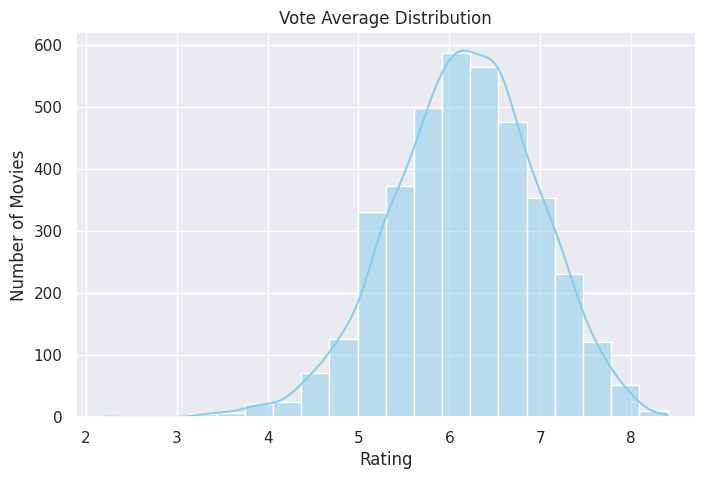

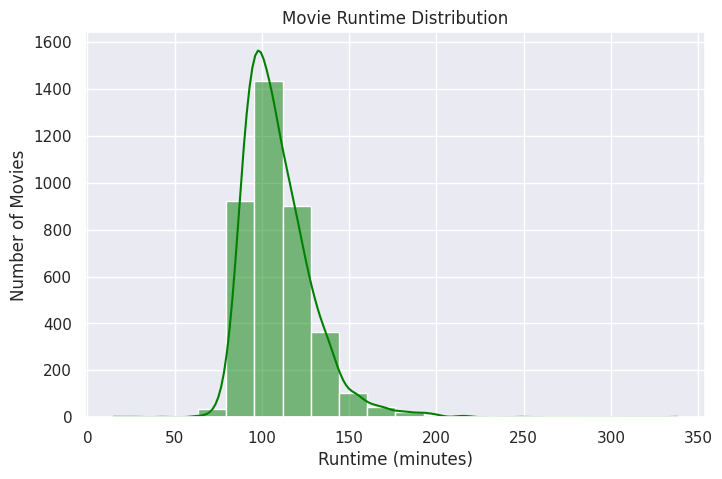

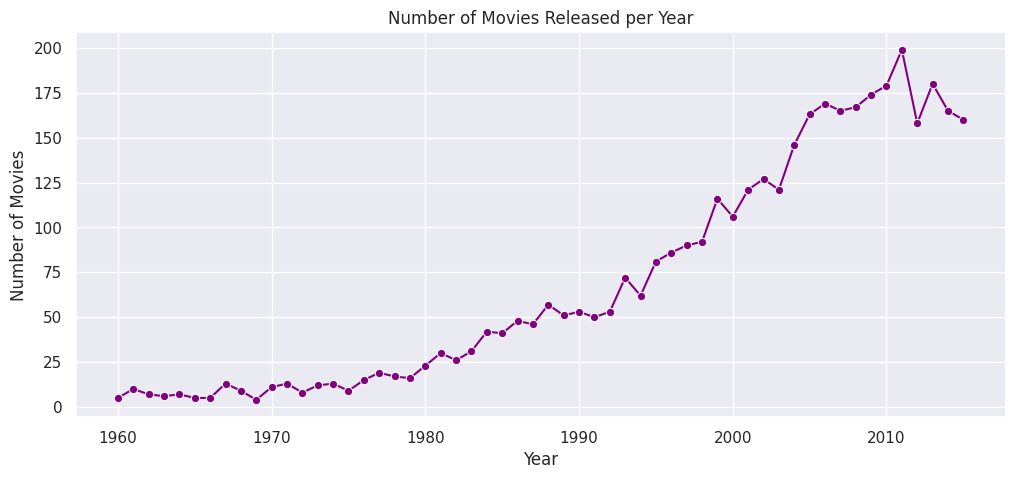

/tmp/ipykernel_7891/408772154.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='genres', y='count', palette='Oranges_r')


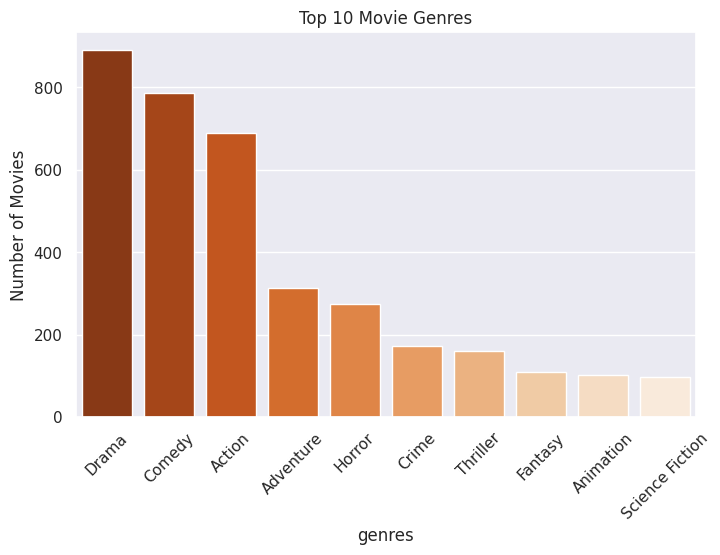

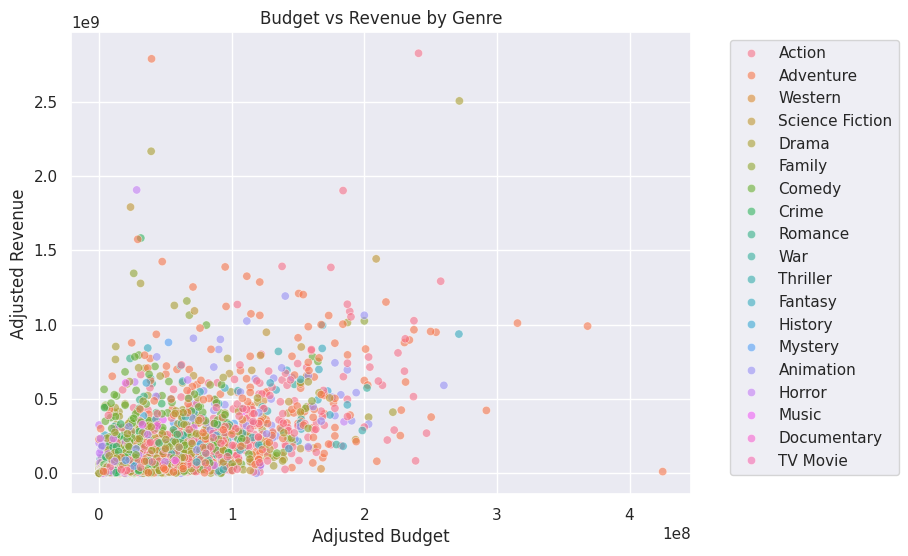

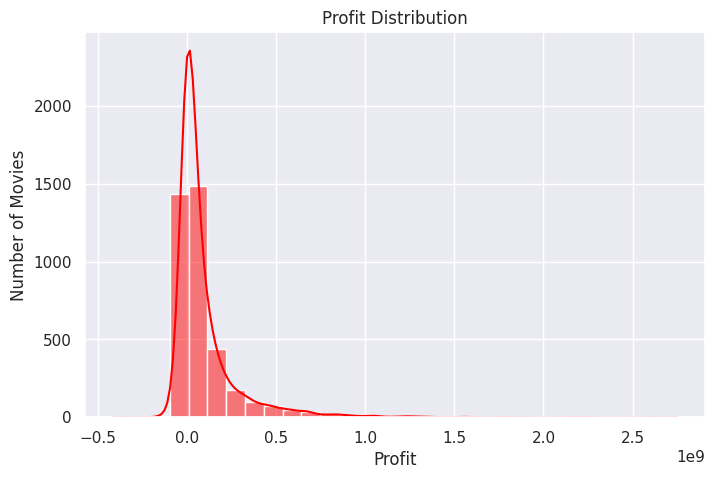

/tmp/ipykernel_7891/408772154.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_rating, x='genres', y='vote_average', palette='cool')


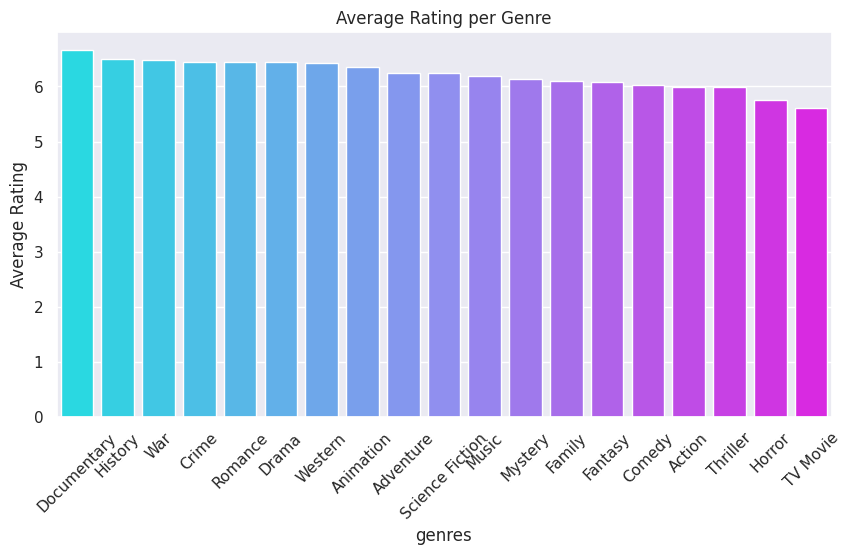

/tmp/ipykernel_7891/408772154.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_directors, x='director', y='count', palette='magma')


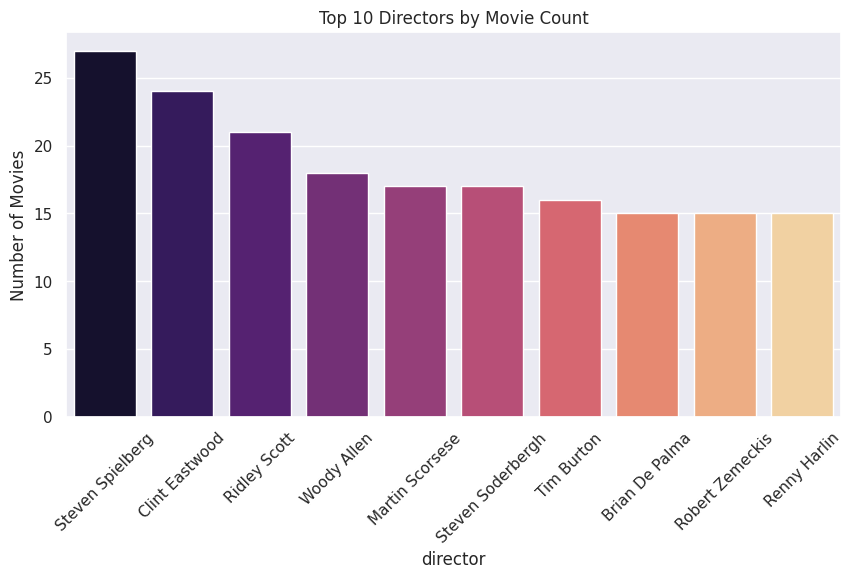

In [ ]:
# a) Vote Average Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['vote_average'], bins=20, kde=True, color='skyblue')
plt.title('Vote Average Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.show()

# b) Runtime Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['runtime'], bins=20, kde=True, color='green')
plt.title('Movie Runtime Distribution')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.show()

# c) Movies Released per Year
movies_per_year = df.groupby('release_year').size().reset_index(name='count')
plt.figure(figsize=(12,5))
sns.lineplot(data=movies_per_year, x='release_year', y='count', marker='o', color='purple')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

# d) Top 10 Genres
top_genres = df['genres'].value_counts().head(10).reset_index()
top_genres.columns = ['genres','count']
plt.figure(figsize=(8,5))
sns.barplot(data=top_genres, x='genres', y='count', palette='Oranges_r')
plt.title('Top 10 Movie Genres')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.show()

# e) Budget vs Revenue by Genre
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='budget_adj', y='revenue_adj', hue='genres', alpha=0.6)
plt.title('Budget vs Revenue by Genre')
plt.xlabel('Adjusted Budget')
plt.ylabel('Adjusted Revenue')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

# f) Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['profit'], bins=30, kde=True, color='red')
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Number of Movies')
plt.show()

# g) Average Rating per Genre
genre_rating = df.groupby('genres')['vote_average'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=genre_rating, x='genres', y='vote_average', palette='cool')
plt.title('Average Rating per Genre')
plt.xticks(rotation=45)
plt.ylabel('Average Rating')
plt.show()

# h) Top 10 Directors by Movie Count
top_directors = df['director'].value_counts().head(10).reset_index()
top_directors.columns = ['director','count']
plt.figure(figsize=(10,5))
sns.barplot(data=top_directors, x='director', y='count', palette='magma')
plt.title('Top 10 Directors by Movie Count')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.show()